In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_lauda = pd.read_csv("curva_lauda.csv")
df_lauda.head()

,caudal_lmin,presion_bar
0,0,0.20000
1,2,0.17600
2,4,0.15625
3,6,0.13750
4,8,0.11300


In [4]:
x = df_lauda["caudal_lmin"]
y = df_lauda["presion_bar"]
x = x * 1.6667e-5
y = y * 100000
coef = np.polyfit(x,y,2)
print(coef)
p = np.poly1d(coef) # Crea una función evaluable con esos coeficientes

# 2. Generar puntos para una curva suave en el gráfico
x_curva = np.linspace(min(x), max(x), 100)
y_curva = p(x_curva)

[-1.23667290e+11 -4.50879282e+07  1.95608371e+04]


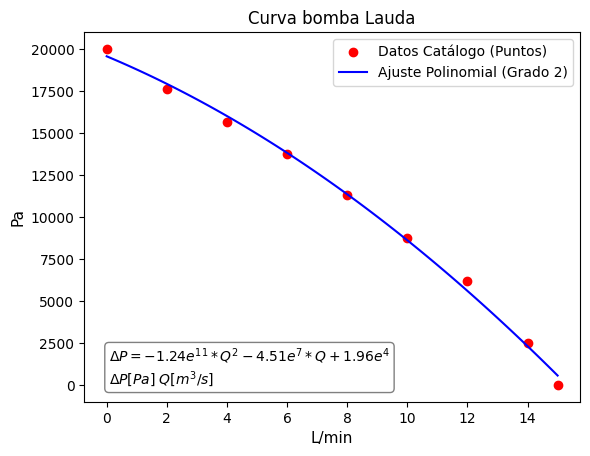

In [9]:
plt.figure()

# Dibujar puntos originales
plt.scatter(x*1000*60, y, color='red', label='Datos Catálogo (Puntos)')

# Dibujar curva ajustada
plt.plot(x_curva*1000*60, y_curva, '-', color='blue', label='Ajuste Polinomial (Grado 2)')
plt.annotate(
text=r"$\Delta P = -1.24e^{11} * Q^2 - 4.51e^7 *Q + 1.96e^4$"+ "\n" + r"$\Delta P[Pa]$ $Q[m^3/s]$",
    xy=(0.05, 0.05),              # (X, Y) Posición: 5% a la derecha, 5% hacia arriba
    xycoords='axes fraction',     # Las coordenadas son relativas al tamaño del gráfico
    fontsize=10,                  # Opcional: tamaño de la letra
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1) # Opcional: le pone una cajita de fondo
)
plt.title('Curva bomba Lauda', fontsize=12)
plt.xlabel('L/min', fontsize=11)
plt.ylabel('Pa', fontsize=11)
plt.legend()
plt.show()

In [6]:
coef_inv = np.polyfit(y, x, 2)
print(coef_inv)
Q_func = np.poly1d(coef_inv)


invy_curva = np.linspace(0,20000, 100)
invx_curva = Q_func(invy_curva)

[-2.71801833e-13 -7.42566003e-09  2.52500090e-04]


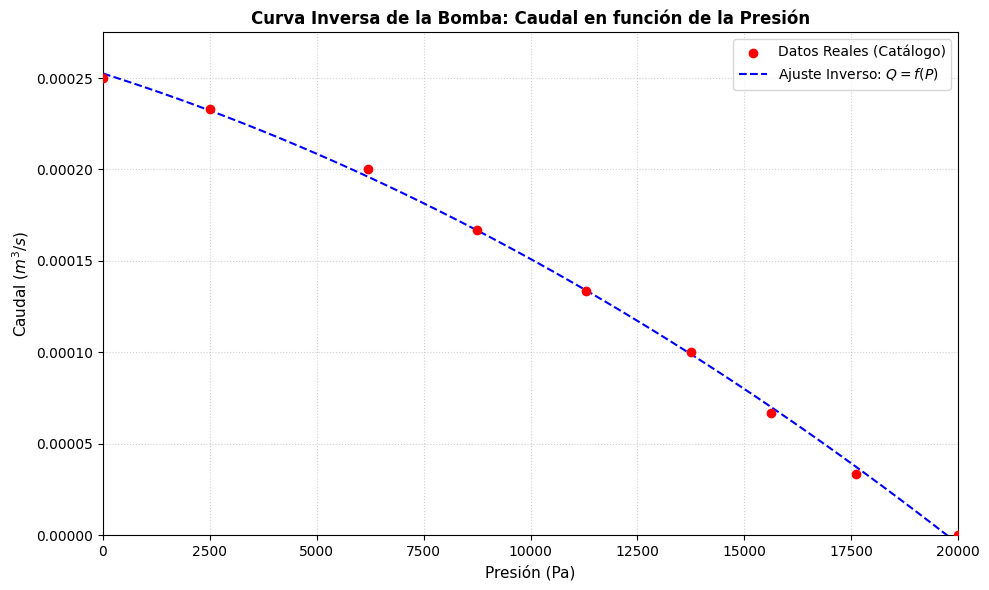

In [7]:
plt.figure(figsize=(10, 6))

# Puntos reales del catálogo
plt.scatter(y, x, color='red', label='Datos Reales (Catálogo)', zorder=5)

# Curva ajustada inversa
plt.plot(invy_curva, invx_curva, color='blue', linestyle='--', label='Ajuste Inverso: $Q = f(P)$')

# Configuración de etiquetas y formato
plt.title('Curva Inversa de la Bomba: Caudal en función de la Presión', fontsize=12, fontweight='bold')
plt.xlabel('Presión (Pa)', fontsize=11)
plt.ylabel('Caudal ($m^3/s$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Limitar los ejes para una mejor visualización
plt.xlim(0, 20000)
plt.ylim(0, max(x) * 1.1)

plt.tight_layout()
plt.show()